# Extension: Bootstrap Confidence Intervals for Gender Differences in VIQ

This notebook extends the brain_size analysis with **bootstrap confidence intervals**, a resampling method not covered in the main walkthrough. Bootstrap CIs make fewer distributional assumptions than standard t-based intervals and are useful for small samples.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

NOTEBOOKS = Path('../manual/notebooks')
brain = pd.read_csv(NOTEBOOKS / 'brain_size.csv', sep=';', na_values='.')
male_viq = brain.loc[brain['Gender'] == 'Male', 'VIQ'].values
female_viq = brain.loc[brain['Gender'] == 'Female', 'VIQ'].values
observed_diff = male_viq.mean() - female_viq.mean()
print(f'Observed mean VIQ difference (Male - Female): {observed_diff:.2f}')

Observed mean VIQ difference (Male - Female): 5.80


## Bootstrap procedure

1. Resample males and females **with replacement** within each group.
2. Compute the mean VIQ difference for each resample.
3. Use the 2.5th and 97.5th percentiles as a 95% bootstrap confidence interval.

In [2]:
rng = np.random.default_rng(42)
n_bootstrap = 10000
boot_diffs = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    boot_m = rng.choice(male_viq, size=len(male_viq), replace=True)
    boot_f = rng.choice(female_viq, size=len(female_viq), replace=True)
    boot_diffs[i] = boot_m.mean() - boot_f.mean()

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
print(f'95% bootstrap CI for VIQ difference: [{ci_low:.2f}, {ci_high:.2f}]')
contains_zero = ci_low <= 0 <= ci_high
print('CI contains 0:' , contains_zero)

95% bootstrap CI for VIQ difference: [-8.80, 20.30]
CI contains 0: True


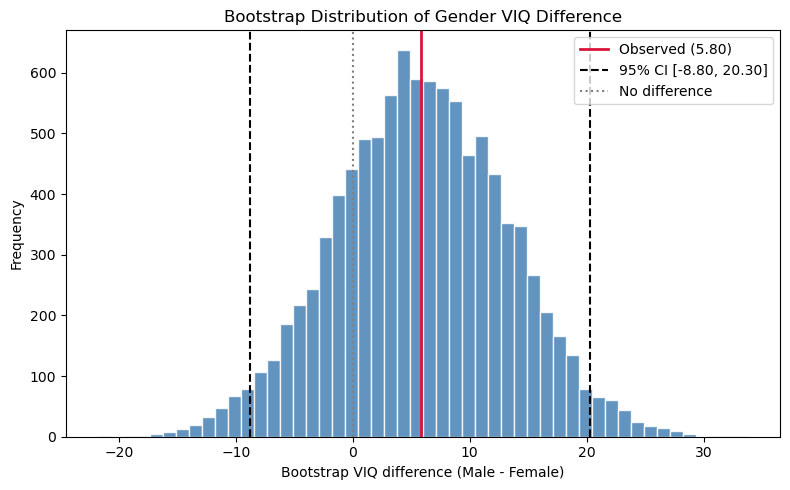

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(boot_diffs, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(observed_diff, color='crimson', linewidth=2, label=f'Observed ({observed_diff:.2f})')
ax.axvline(ci_low, color='black', linestyle='--', label=f'95% CI [{ci_low:.2f}, {ci_high:.2f}]')
ax.axvline(ci_high, color='black', linestyle='--')
ax.axvline(0, color='gray', linestyle=':', label='No difference')
ax.set_xlabel('Bootstrap VIQ difference (Male - Female)')
ax.set_ylabel('Frequency')
ax.set_title('Bootstrap Distribution of Gender VIQ Difference')
ax.legend()
plt.tight_layout()
plt.show()

## Extension conclusion

The bootstrap 95% confidence interval for the male–female VIQ mean difference provides a distribution-free uncertainty estimate. If the interval includes zero, we cannot reject a null of no gender difference in VIQ at the 95% level—consistent with the classical t-test and Mann-Whitney results in the main notebook.